In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
ts, vs = np.loadtxt("spoke_potential.csv", delimiter=",").T

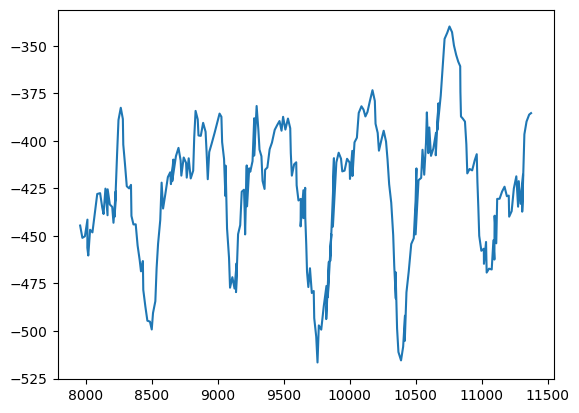

In [5]:
plt.plot(ts, vs)

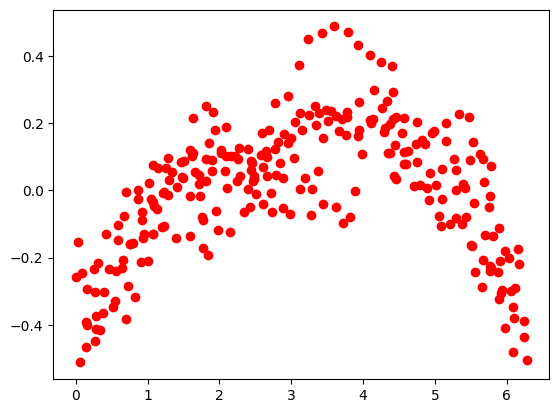

In [6]:
phis = (ts - 150) % 640 / 640 * 2 * np.pi
vs -= vs.mean()
vs /= vs.max() - vs.min()


plt.plot(phis, vs, "ro")

C:\Users\vano2\AppData\Local\Temp\ipykernel_6092\2863701493.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(f, phis, vs)


Text(0, 0.5, 'V')

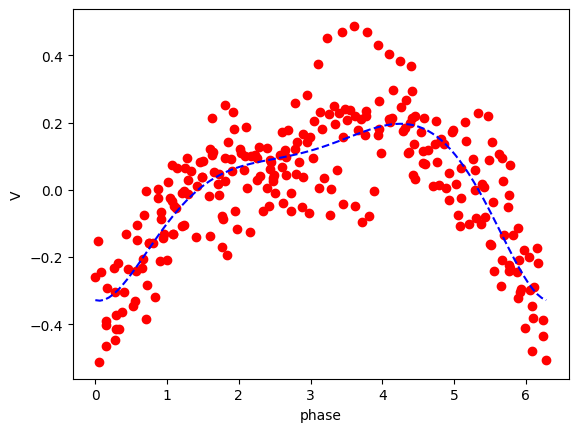

In [7]:
def f(x, a, b, c, d, e, f, g):
    p = 2 * np.pi
    e = -0.5 * p * (6 * a * p**3 + 5 * b * p**2 + 4 * c * p + 3 * d)
    f = -a * p**5 - b * p**4 - c * p**3 - d * p**2 - e * p
    return a * x**6 + b * x**5 + c * x**4 + d * x**3 + e * x**2 + f * x + g


popt, pcov = curve_fit(f, phis, vs)

plt.plot(phis, vs, "ro")
xs = np.linspace(0, 2 * np.pi, 100)
ys = f(xs, *popt)
plt.plot(xs, ys, "b--")
plt.xlabel("phase")
plt.ylabel("V")

0.0 1.0


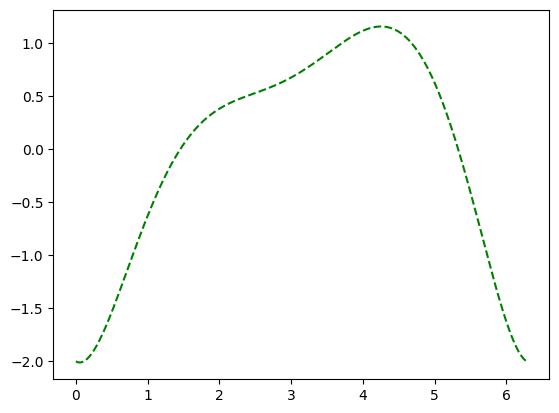

In [16]:
xs = np.linspace(0, 2 * np.pi, 1000)
ys = f(xs, *popt)
mean_f = ys.mean()
std_f = ys.std()


def f_phi_normalized(x, popt):
    return (f(x, *popt) - mean_f) / std_f


ys_normalized = f_phi_normalized(xs, popt)
plt.plot(xs, ys_normalized, "g--")
print(ys_normalized.mean(), ys_normalized.std())

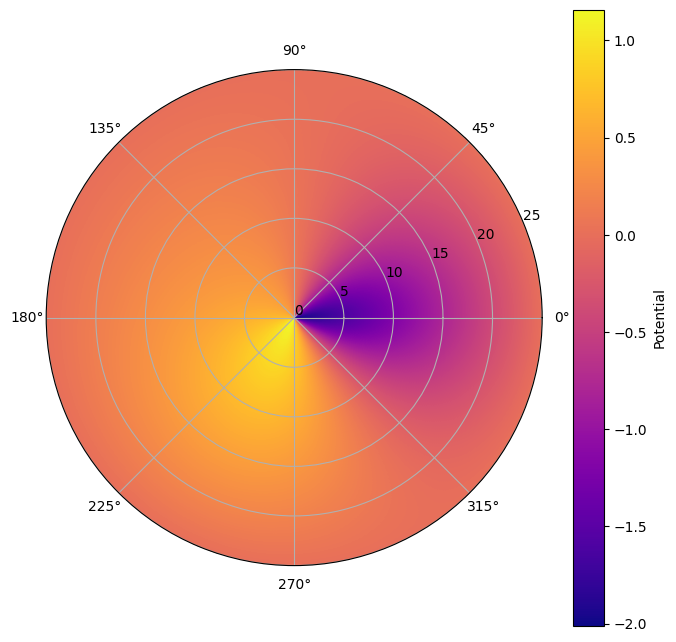

In [ ]:
thetas = np.linspace(0, 2 * np.pi, 1000)
rs = np.linspace(0, 25, 1000)


def f_r_phi(r, theta, popt, v_max, r_max):
    return f_phi_normalized(theta, popt) * v_max * (r_max - r) / r_max * (r < r_max)




theta_grid, r_grid = np.meshgrid(thetas, rs)
z_grid = f_r_phi(r_grid, theta_grid, popt, 1, 25)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))
c = ax.pcolormesh(theta_grid, r_grid, z_grid, shading="auto", cmap="plasma")
fig.colorbar(c, ax=ax, label="Potential")
plt.show()

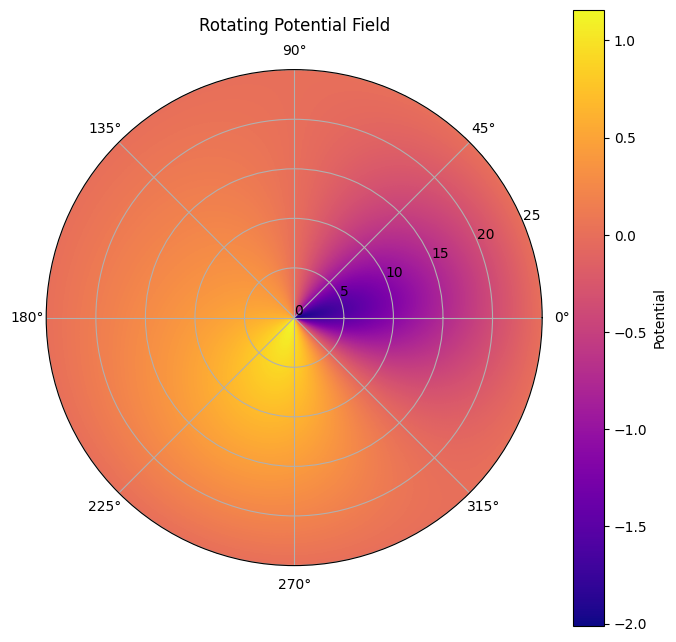

In [18]:
import matplotlib.animation as animation
from IPython.display import HTML

# Define parameters
thetas = np.linspace(0, 2 * np.pi, 1000)
r_max = 25
v_max = 1
rs = np.linspace(0, r_max, 1000)
n_frames = 100  # Number of frames in the animation
speed = 2 * np.pi / n_frames  # Speed of rotation


# Create grid
theta_grid, r_grid = np.meshgrid(thetas, rs)
z_grid = f_r_phi(r_grid, theta_grid, popt, 1, r_max)

# Initialize plot
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))
c = ax.pcolormesh(theta_grid, r_grid, z_grid, shading="auto", cmap="plasma")
fig.colorbar(c, ax=ax, label="Potential")

ax.set_title("Rotating Potential Field", va="bottom")


# Animation function
def update(frame):
    global theta_grid
    theta_grid -= speed  # Update theta_grid
    theta_grid %= 2 * np.pi
    z_grid = f_r_phi(r_grid, theta_grid, popt, v_max, r_max)
    c.set_array(z_grid.ravel())
    return (c,)


# Create animation
ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)
ani.save("polar_animation.mp4", writer="ffmpeg", fps=25)
# Display in Jupyter Notebook
# HTML(ani.to_jshtml())  # or ani.to_html5_video()

In [19]:
xs = np.linspace(-r_max, r_max, 250, dtype="float32")
phases = np.linspace(0, 2 * np.pi, 250, dtype="float32")
dx = xs[1] - xs[0]
x_grid, y_grid, phase_grid = np.meshgrid(xs, xs, phases)
r_grid = np.sqrt(x_grid**2 + y_grid**2)
theta_grid = (np.atan2(y_grid, x_grid) + phase_grid) % (2 * np.pi)
z_grid = f_r_phi(r_grid, theta_grid, popt, 1, r_max)

ex_grid = -np.gradient(z_grid, dx, axis=0)
ey_grid = -np.gradient(z_grid, dx, axis=1)

In [20]:
# j = 5500
# i = 5000
# print(x_grid[i, j], y_grid[i, j])
# print(ex_grid[i, j], ey_grid[i, j])

In [23]:
x_grid_flat = x_grid.ravel()
y_grid_flat = y_grid.ravel()
phase_grid_flat = phase_grid.ravel()
ex_grid_flat = ex_grid.ravel()
ey_grid_flat = ey_grid.ravel()
np.savez_compressed("fluctuation_x_y_phase.npz", Ex=ex_grid_flat, Ey=ey_grid_flat)

In [ ]:
# x, y, phase, ex, ey = np.loadtxt(
#     "fluctuation_x_y_phase.csv", delimiter=",", skiprows=1
# ).T
# x = x.reshape((250, 250, 250))
# y = y.reshape((250, 250, 250))
# phase = phase.reshape((250, 250, 250))
# ex = ex.reshape((250, 250, 250))
# ey = ey.reshape((250, 250, 250))
# e_abs = np.sqrt(ex**2 + ey**2)
# print(phase[0, 0, 0], phase[0, 0, 1])

KeyboardInterrupt: 

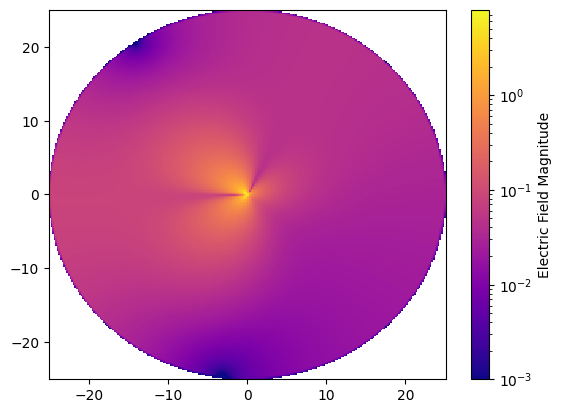

In [ ]:
import matplotlib.colors as colors

plt.pcolormesh(
    x[:, :, 125],
    y[:, :, 125],
    e_abs[:, :, 125],
    shading="auto",
    cmap="plasma",
    norm=colors.LogNorm(1e-3, vmax=e_abs.max()),
)
plt.colorbar(label="Electric Field Magnitude")